In [1]:
import pandas as pd

In [2]:
tips_url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
tips = pd.read_csv(tips_url)
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [3]:
tips.shape

(244, 7)

In [4]:
tips.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    str    
 3   smoker      244 non-null    str    
 4   day         244 non-null    str    
 5   time        244 non-null    str    
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), str(4)
memory usage: 13.5 KB


In [5]:
tips.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [6]:
tips['tip_pct'] = (tips['tip'] / tips['total_bill']) * 100
tips.head()

,total_bill,tip,sex,smoker,day,time,size,tip_pct
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054159
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978041
4,24.59,3.61,Female,No,Sun,Dinner,4,14.680765


In [9]:
tips[tips['total_bill'] > 20].head()

,total_bill,tip,sex,smoker,day,time,size,tip_pct
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978041
4,24.59,3.61,Female,No,Sun,Dinner,4,14.680765
5,25.29,4.71,Male,No,Sun,Dinner,4,18.623962
7,26.88,3.12,Male,No,Sun,Dinner,4,11.607143


In [11]:
tips.sort_values('tip_pct', ascending=True).head()

,total_bill,tip,sex,smoker,day,time,size,tip_pct
237,32.83,1.17,Male,Yes,Sat,Dinner,2,3.563814
102,44.30,2.50,Female,Yes,Sat,Dinner,3,5.643341
57,26.41,1.50,Female,No,Sat,Dinner,2,5.679667
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673
187,30.46,2.00,Male,Yes,Sun,Dinner,5,6.565988


In [12]:
tips.groupby('day')['total_bill'].mean()

day
Fri     17.151579
Sat     20.441379
Sun     21.410000
Thur    17.682742
Name: total_bill, dtype: float64

In [15]:
tips.groupby(['day', 'time'])[['total_bill', 'tip', 'tip_pct']].mean()


total_bill       tip    tip_pct
day  time                                   
Fri  Dinner   19.663333  2.940000  15.891611
     Lunch    12.845714  2.382857  18.876489
Sat  Dinner   20.441379  2.993103  15.315172
Sun  Dinner   21.410000  3.255132  16.689729
Thur Dinner   18.780000  3.000000  15.974441
     Lunch    17.664754  2.767705  16.130074

In [16]:
tips['day'].value_counts()

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

In [17]:
tips.pivot_table(
    index='day',
    columns='smoker',
    values='tip_pct',
    aggfunc='mean'
)

smoker,No,Yes
day,,
Fri,15.165044,17.478305
Sat,15.804766,14.790607
Sun,16.011294,18.725032
Thur,16.029808,16.386327


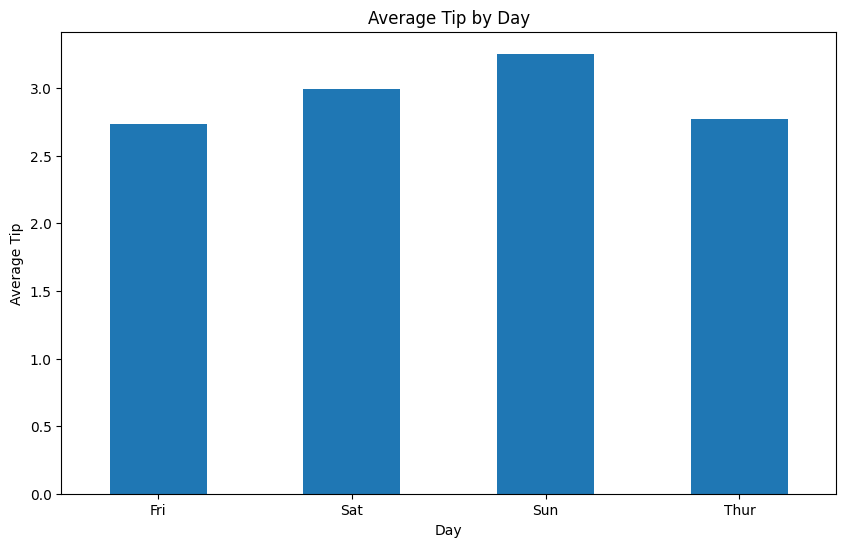

In [20]:
import matplotlib.pyplot as plt

avg_tip_by_day = tips.groupby('day')['tip'].mean()

plt.figure(figsize=(10, 6))
avg_tip_by_day.plot(kind='bar')
plt.xlabel('Day')
plt.ylabel('Average Tip')
plt.title('Average Tip by Day')
plt.xticks(rotation=0)
plt.show()

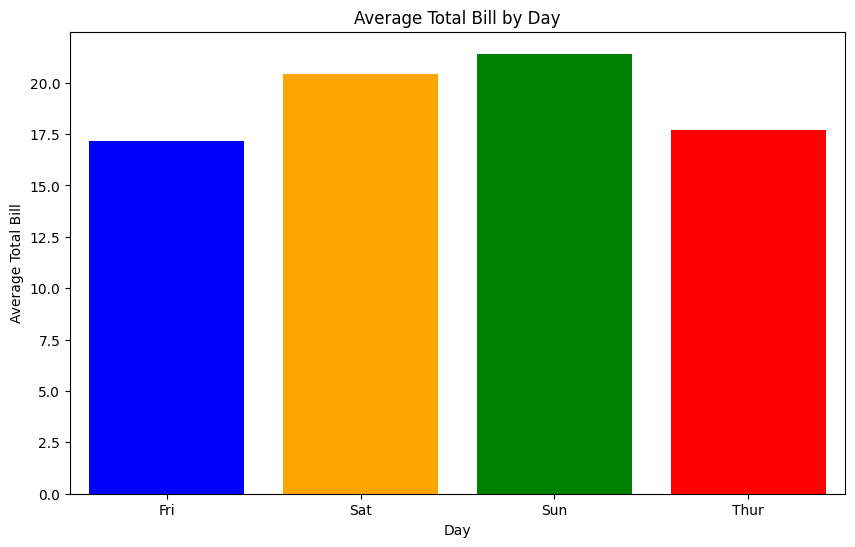

In [21]:
avg_bill_by_day = tips.groupby('day')['total_bill'].mean()

plt.figure(figsize=(10, 6))
avg_bill_by_day.plot(kind='bar')
# Set colors of the bars
plt.bar(avg_bill_by_day.index, avg_bill_by_day.values, color=['blue', 'orange', 'green', 'red'])
plt.xlabel('Day')
plt.ylabel('Average Total Bill')
plt.title('Average Total Bill by Day')
plt.xticks(rotation=0)
plt.show()

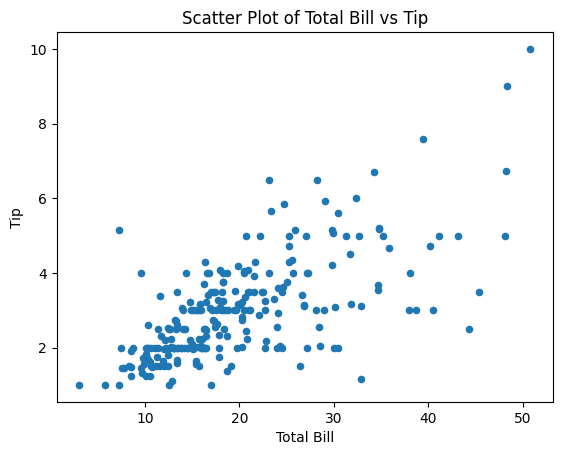

In [22]:
tips.plot(kind='scatter', x='total_bill', y='tip')
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.title('Scatter Plot of Total Bill vs Tip')
plt.show()

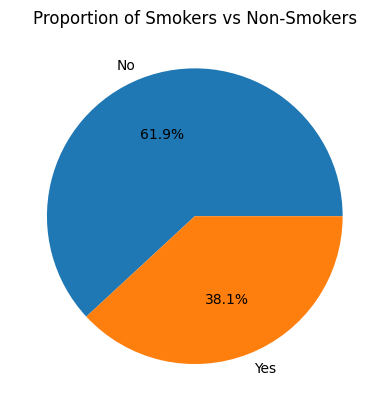

In [23]:
smoker_counts = tips['smoker'].value_counts()
smoker_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title('Proportion of Smokers vs Non-Smokers')
plt.ylabel('')
plt.show()